In [35]:
import torch
import torch.nn as nn
import torch.optim as opt

import h_util2

In [36]:
d = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

t = torch.tensor([[6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

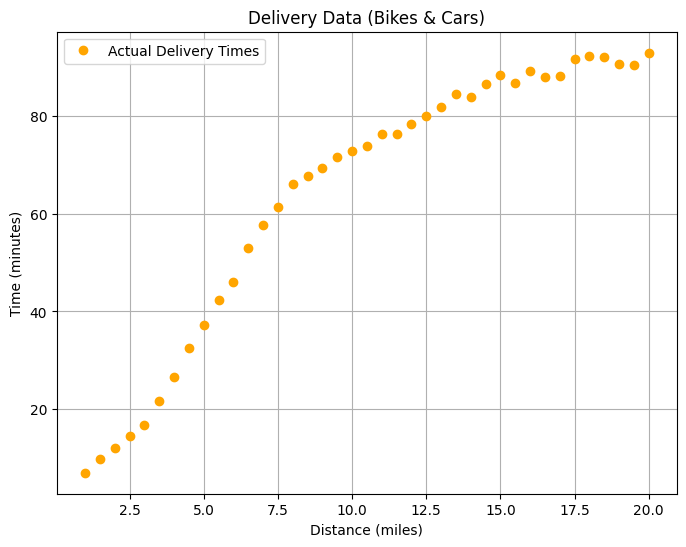

In [37]:
h_util2.plot_data(d, t)

In [38]:
d_mean = d.mean()
t_mean = t.mean()
d_std = d.std()
t_std = t.std()

d_norm = (d - d_mean) / d_std
t_norm = (t - t_mean) / t_std

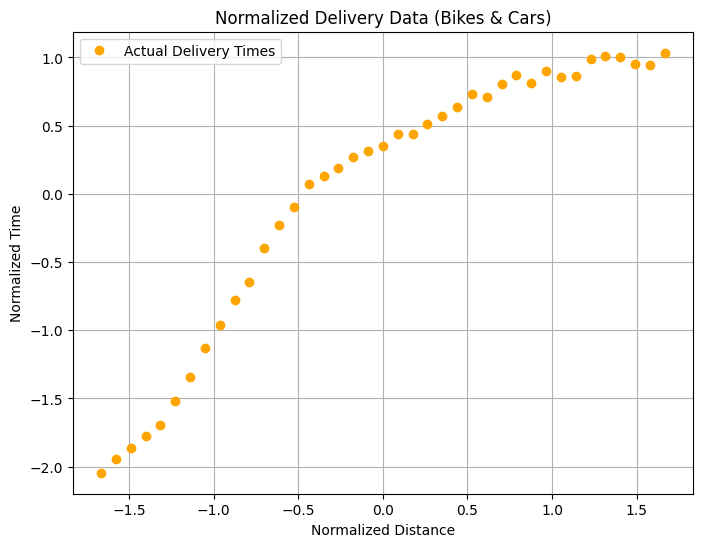

In [39]:
h_util2.plot_data(d_norm, t_norm, normalize=True)

In [40]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

In [41]:
loss_fn = nn.MSELoss()
optimizer = opt.SGD(model.parameters(), lr=0.01)

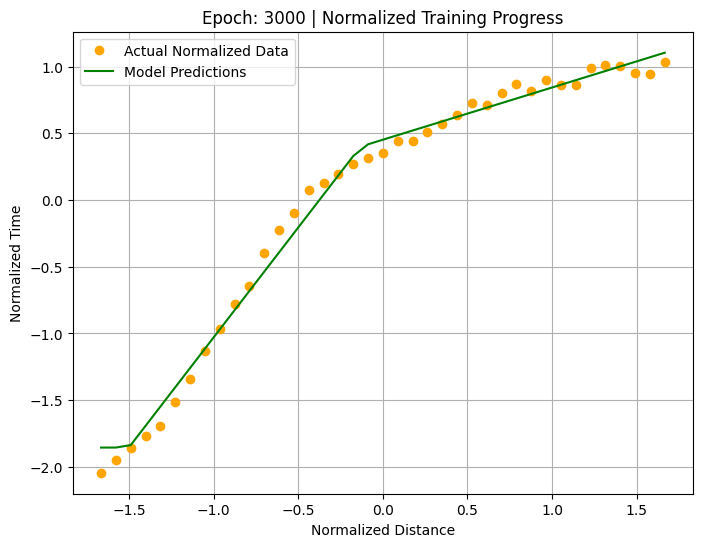


Training complete.

Final loss: 0.0078


In [42]:
for epoch in range(3000):
    optimizer.zero_grad()
    out = model(d_norm)
    loss = loss_fn(out, t_norm)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        h_util2.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=d_norm, 
            times_norm=t_norm
        )

print("\nTraining complete.")
print(f"\nFinal loss: {loss.item():.4f}")

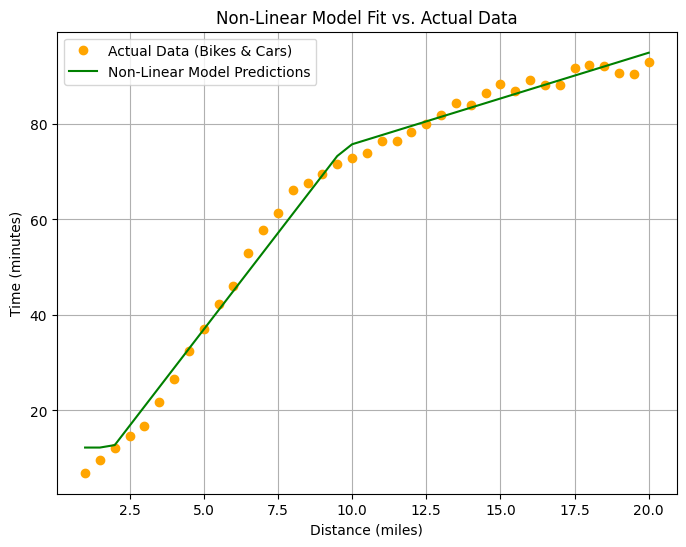

In [43]:
h_util2.plot_final_fit(model,d,t,d_norm,t_std,t_mean)

In [44]:
d_to_predict = 5.1

In [45]:
with torch.no_grad():
    d_tensor = torch.tensor([[d_to_predict]], dtype=torch.float32)
    d_tensor_norm = (d_tensor - d_mean) / d_std 
    
    pred_t_norm = model(d_tensor_norm)
    
    pred_t_actual = pred_t_norm * t_std + t_mean
print(f"\nPredicted time for distance {d_to_predict} is: {pred_t_actual.item():.2f} seconds")

if pred_t_actual.item() > 45:
    print("\nDecision : Do NOT promise delivery within 45 minutes.")
else:
    if d_to_predict <= 3:
        print(f"\nDecision : Yes delivery is possible, Since the distance is {d_to_predict} miles (<= 3 miles), use a bike ")
    else:        print(f"\nDecision : Yes delivery is possible, Since the distance is {d_to_predict} miles (> 3 miles), use a car ")


Predicted time for distance 5.1 is: 37.77 seconds

Decision : Yes delivery is possible, Since the distance is 5.1 miles (> 3 miles), use a car 
